In [1]:
import numpy as np
from RVSS_Slope_PT import RVSS_EOS_Slope_PT as rvss_pt
from matplotlib import pyplot as plt
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov

In [2]:
n0 = 0.16
MN = 939.56
EPSILON = MN*n0
hc = 197.3

c1 = 0.9008
d1 = 0.5034
d2 = 1.452
nu_1 = 0.3553
nu_2 = 0.9101

In [3]:
def Pqcd(mu_b,X):
    return P_SB(mu_b)*(c1 - (a(X))/((mu_b/1000) - b(X)))

def P_SB(mu_b):
    return (3/(4*np.pi**2))*(mu_b/3)**(4.0)
def a(X):
    return d1*X**(-1*nu_1)
def b(X):
    return d2**X**(-1*nu_2)

In [4]:
Pqcd_upper = Pqcd(2700,4)/(hc**3)
Pqcd_lower = Pqcd(2700,1)/(hc**3)

In [5]:
print(Pqcd_upper)

4590.617567285208


In [6]:
eos_I = rvss_pt(1.41,3*n0)
eos_II = rvss_pt(1.41,6*n0)
eos_III = rvss_pt(1.41,9*n0)

eos_I_B = rvss_pt(2.0,3*n0)
eos_II_B = rvss_pt(2.0,6*n0)
eos_III_B = rvss_pt(2.0,9*n0)

matching pressure: 3.012
mu match: 974.394
n_match: 0.160
cs2 match: 0.051
Done!
matching pressure: 3.012
mu match: 974.394
n_match: 0.160
cs2 match: 0.051
Done!
matching pressure: 3.012
mu match: 974.394
n_match: 0.160
cs2 match: 0.051
Done!
matching pressure: 3.012
mu match: 974.394
n_match: 0.160
cs2 match: 0.051
Done!
matching pressure: 3.012
mu match: 974.394
n_match: 0.160
cs2 match: 0.051
Done!
matching pressure: 3.012
mu match: 974.394
n_match: 0.160
cs2 match: 0.051
Done!


In [7]:
print(eos_I.slope_p_min)

1.4049938565022582


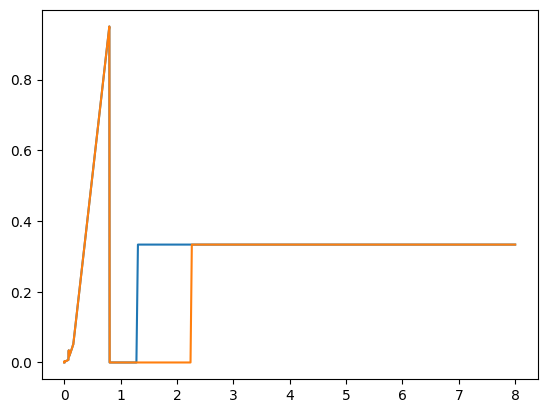

In [8]:
plt.plot(eos_I.nb_tot,eos_I.cs2_tot)

plt.plot(eos_III.nb_tot,eos_III.cs2_tot)

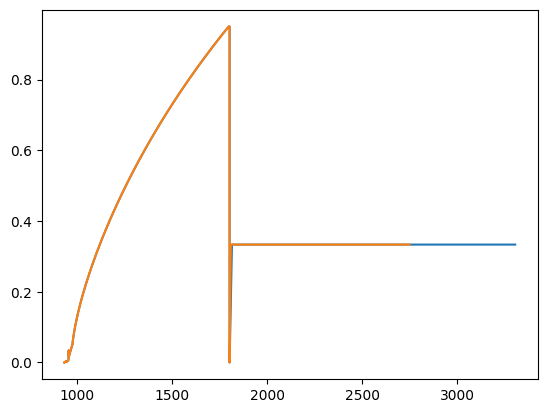

In [9]:
plt.plot(eos_I.mu_tot,eos_I.cs2_tot)

plt.plot(eos_III.mu_tot,eos_III.cs2_tot)
#plt.gca().set_xlim([0,10*n0])

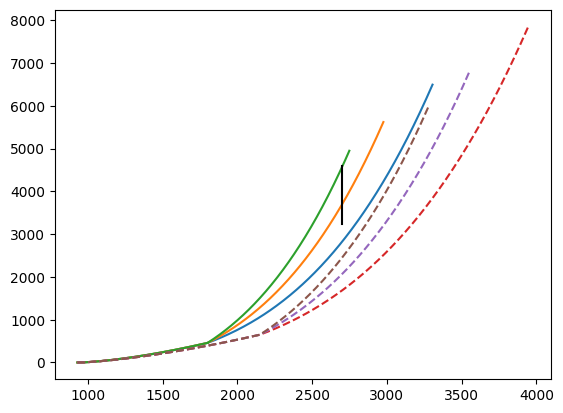

In [9]:
plt.plot(eos_I.mu_tot,eos_I.P_tot)
plt.plot(eos_II.mu_tot,eos_II.P_tot)
plt.plot(eos_III.mu_tot,eos_III.P_tot)

plt.plot(eos_I_B.mu_tot,eos_I_B.P_tot,linestyle='--')
plt.plot(eos_II_B.mu_tot,eos_II_B.P_tot,linestyle='--')
plt.plot(eos_III_B.mu_tot,eos_III_B.P_tot,linestyle='--')
plt.plot([2700,2700],[Pqcd_lower,Pqcd_upper],color='black')

In [10]:
solver_1 = tov(EPSILON,lambda p: eos_I.eos_interp(p*EPSILON)/EPSILON,lambda p: eos_I.dens_interp(p*EPSILON))
solver_III = tov(EPSILON,lambda p: eos_III.eos_interp(p*EPSILON)/EPSILON,lambda p: eos_III.dens_interp(p*EPSILON))

In [ ]:
sol_test = solver_1.solve(0.56,0.001,)

In [13]:
p_central = np.logspace(-2,1,100)
M_I = np.empty_like(p_central)
R_I = np.empty_like(p_central)
mu_C_I = np.empty_like(p_central)

for i,pc in enumerate(p_central):
    sol = solver_1.solve(pc,dr=0.001,dr_max=0.01,rmax=30)
    M_I[i] = sol.y[1,-1]
    R_I[i] = sol.t[-1]
    mu_C_I[i] = (pc*EPSILON + eos_I.eos_interp(pc*EPSILON))/(eos_I.dens_interp(pc*EPSILON))
    print(f'pc:{pc}     M (M_Sol): {M_I[i]}     R(km): {R_I[i]}     mu_c (MeV): {mu_C_I[i]}')

pc:0.01     M (M_Sol): 0.15897684018669844     R(km): 22.639616296693095     mu_c (MeV): 963.7312553870214
pc:0.010722672220103232     M (M_Sol): 0.16599773733991113     R(km): 21.537045584568325     mu_c (MeV): 964.5824801181001
pc:0.011497569953977356     M (M_Sol): 0.17338827010263622     R(km): 20.56996958880483     mu_c (MeV): 965.5191693297787
pc:0.012328467394420659     M (M_Sol): 0.18114961474811678     R(km): 19.740288384985906     mu_c (MeV): 966.4711829952464
pc:0.013219411484660288     M (M_Sol): 0.1893034629880971     R(km): 19.008254249074163     mu_c (MeV): 967.4395248516275
pc:0.014174741629268055     M (M_Sol): 0.1978587127310998     R(km): 18.36756021274933     mu_c (MeV): 968.5136921100018
pc:0.01519911082952934     M (M_Sol): 0.20682772432663932     R(km): 17.798138327083894     mu_c (MeV): 969.6094553414634
pc:0.016297508346206444     M (M_Sol): 0.21623358403023965     R(km): 17.289755897107412     mu_c (MeV): 970.7243661335965
pc:0.01747528400007684     M (M_Sol):

In [14]:
print(max(M_I))

2.358892713879356
